In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import kagglehub
path = kagglehub.dataset_download("debasmitabagchi/ushape-csv")

100%|██████████| 2.68k/2.68k [00:00<00:00, 4.09MB/s]

Extracting files...


In [6]:
import os
print(os.listdir(path))

['ushape.csv']


In [9]:
df = pd.read_csv(os.path.join(path,'ushape.csv'),header=None)

In [10]:
df.head()

,0,1,2
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


In [13]:
X=df.iloc[:,0:2].values
y=df.iloc[:,-1].values

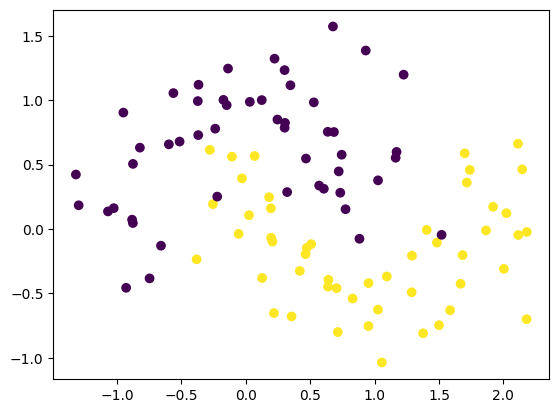

In [15]:
plt.scatter(X[:,0],X[:,1],c=y)

In [17]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()

In [18]:
clf.fit(X,y)

LogisticRegression()

<Axes: >

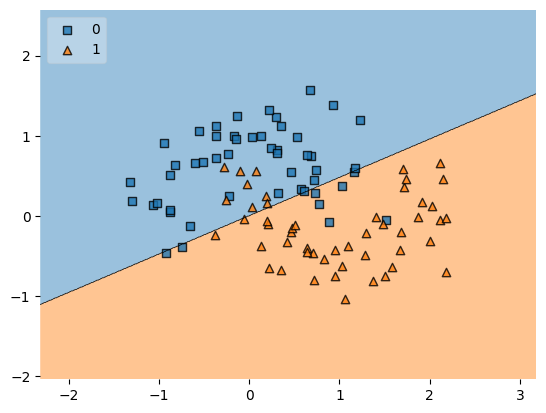

In [23]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'),clf,legend=2)

In [24]:
from sklearn.model_selection import cross_val_score

In [25]:
np.mean(cross_val_score(clf,X,y,scoring='accuracy',cv=10))

np.float64(0.8300000000000001)

In [38]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=4,include_bias=False)
X_trf=poly.fit_transform(X)

In [39]:
clf1=LogisticRegression()
np.mean(cross_val_score(clf1,X_trf,y,scoring='accuracy',cv=10))

np.float64(0.9)

In [40]:
def plot_decision_boundary(X,y,degree=1):

    poly = PolynomialFeatures(degree=degree)
    X_trf = poly.fit_transform(X)

    clf = LogisticRegression()
    clf.fit(X_trf,y)

    accuracy = np.mean(cross_val_score(clf,X_trf,y,scoring='accuracy',cv=10))

    a=np.arange(start=X[:,0].min()-1, stop=X[:,0].max()+1, step=0.01)
    b=np.arange(start=X[:,1].min()-1, stop=X[:,1].max()+1, step=0.01)


    XX,YY=np.meshgrid(a,b)

    input_array=np.array([XX.ravel(),YY.ravel()]).T

    labels=clf.predict(poly.transform(input_array))

    plt.contourf(XX,YY,labels.reshape(XX.shape),alpha=0.5)
    plt.scatter(X[:,0],X[:,1], c=y)
    plt.title('Degree = {}, accuracy is {}'.format(degree,np.round(accuracy,4)))

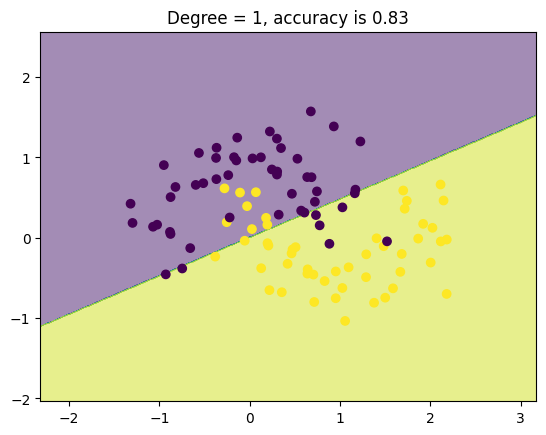

In [42]:
plot_decision_boundary(X,y)

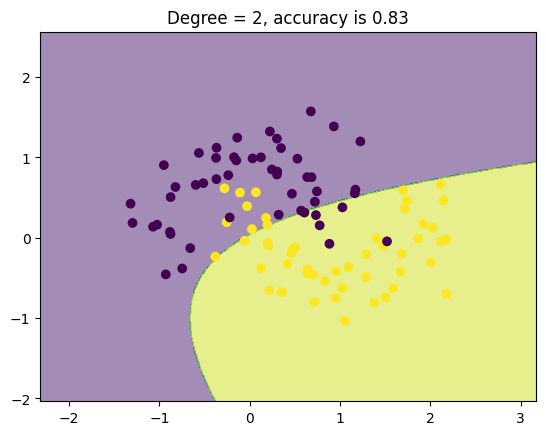

In [43]:
plot_decision_boundary(X,y,2)

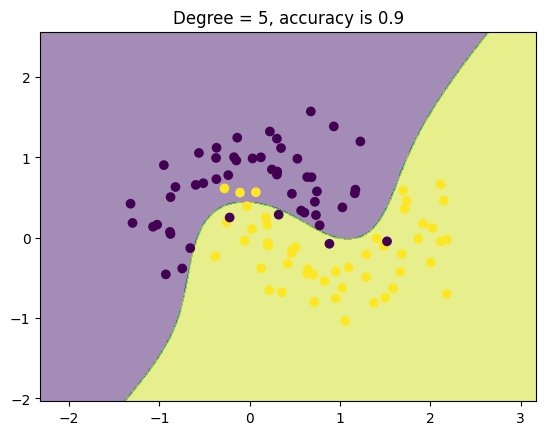

In [46]:
plot_decision_boundary(X,y,5)